# Modelo unidimensional simplificado de escoamento em canal inspirado no Backward-Facing Step via diferenças finitas

## Problema e Metodologia
O BFS completo é governado por Navier-Stokes 2D. Neste trabalho, considera-se uma região afastada da recirculação, onde o escoamento pode ser aproximado como laminar, permanente e totalmente desenvolvido, reduzindo o problema a uma EDO de segunda ordem para o perfil de velocidade.

Considerou-se uma região simplificada do escoamento, suficientemente afastada da zona de recirculação, onde o campo de velocidades pode ser aproximado por uma única componente predominante. Sob essa hipótese, obtém-se uma equação diferencial ordinária do tipo Poisson, utilizada como problema-modelo para validação do método de diferenças finitas. Assim, o objetivo desta etapa não é reproduzir integralmente o escoamento no BFS, mas investigar numericamente o comportamento de uma componente da velocidade em um cenário fisicamente consistente e matematicamente tratável.

## Introdução

A Dinâmica dos Fluidos Computacional (Computational Fluid Dynamics – CFD) constitui uma importante ferramenta para a análise e compreensão de fenômenos de escoamento presentes em diversos problemas de engenharia, como sistemas de transporte de fluidos, máquinas hidráulicas, aerodinâmica e processos industriais. Entre os problemas clássicos de CFD, destaca-se o escoamento em canal com degrau (*Backward-Facing Step* – BFS), amplamente utilizado como benchmark para validação de modelos numéricos devido à presença de fenômenos complexos, como separação da camada limite, recirculação e reanexação do escoamento.

A modelagem completa do problema de BFS é governada pelas equações de Navier-Stokes bidimensionais, cuja resolução numérica exige o emprego de métodos computacionais avançados, como volumes finitos, elementos finitos ou diferenças finitas aplicadas a Equações Diferenciais Parciais (EDPs). Entretanto, para fins didáticos e em conformidade com os objetivos desta atividade, propõe-se a construção de um modelo simplificado, capaz de preservar o contexto físico do problema sem a necessidade de resolver toda a complexidade do escoamento.

Assim, considera-se uma região do canal suficientemente distante da zona de recirculação, na qual o escoamento pode ser aproximado como laminar, permanente, incompressível e totalmente desenvolvido. Sob essas hipóteses, as componentes convectivas tornam-se desprezíveis e o problema reduz-se a uma Equação Diferencial Ordinária (EDO) de segunda ordem que descreve a distribuição de velocidade na direção transversal ao escoamento.

A equação governante simplificada pode ser escrita como:

$$\mu \frac{d^2u}{dy^2}=\frac{dp}{dx}$$

ou, de forma equivalente,

$$\frac{d^2u}{dy^2}=C$$

em que ($u(y)$) representa a velocidade do fluido, ($\mu$) é a viscosidade dinâmica e ($C$) corresponde a um gradiente de pressão constante.

A resolução dessa EDO será realizada por meio do Método das Diferenças Finitas (MDF), uma das técnicas numéricas mais utilizadas para a discretização de equações diferenciais. O método consiste em substituir as derivadas contínuas por aproximações algébricas obtidas a partir de uma malha discreta do domínio, convertendo o problema diferencial em um sistema de equações lineares passível de solução computacional.

Como etapa complementar, propõe-se a organização do desenvolvimento em um pipeline computacional estruturado, contemplando a formulação física do problema, a discretização numérica, a implementação computacional, a validação por meio da solução analítica e a análise de convergência da solução. Essa abordagem permite não apenas o estudo dos fundamentos de métodos numéricos aplicados à mecânica dos fluidos, mas também estabelece uma ponte conceitual com problemas de maior complexidade, como as simulações CFD do *Backward-Facing Step* e as pesquisas em modelagem computacional baseada em física.

## 1. Definição do Problema Físico

Considera-se uma região simplificada do escoamento após o degrau (*Backward-Facing Step* – BFS), suficientemente distante da zona de recirculação, de modo que o escoamento possa ser aproximado como **unidimensional, permanente, incompressível e totalmente desenvolvido**. Nessas condições, admite-se que a componente horizontal da velocidade dependa apenas da coordenada transversal (y), isto é,

$$
\frac{d^2u}{dy^2}
=
\frac{1}{\mu}\frac{dp}{dx}
$$

onde,

$$
u(y)=U_x(y).
$$

em que:
* ($u(y)$) é a componente horizontal da velocidade;

* ($\mu$) é a viscosidade dinâmica do fluido;

* ($\frac{dp}{dx}$) representa o gradiente de pressão longitudinal;

* ($\frac{1}{\mu}\frac{dp}{dx}$) representa a intensidade média da força motriz do escoamento;

Assim, a equação governante adotada neste trabalho é dada por:

$$
\frac{d^2u}{dy^2}
= S_u(y)
$$

Nessa formulação:

* ($S_u(y)$) é o termo fonte associado à distribuição da velocidade (componente horizontal).

In [2]:
# Bibliotecas
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from tabulate import tabulate
from scipy.interpolate import interp1d

# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_CFD = PATH_DIR / 'bfs2dData/postProcessing' # diretório dos dados CFD
PATH_DATA = PATH_DIR / 'data' # diretório dos dados experimentais
print(PATH_CFD)
print(PATH_DATA)

/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/bfs2dData/postProcessing
/home/matheus/Documentos/Mestrado/modelagem_computacional/bfsDifFinitas/data


## Processamento de Dados

## Dados de gridPoints

In [9]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def load_case(case_dir: str, file_name: str) -> pd.DataFrame:
    """
    Carrega o {file_name} do último tempo do caso.
    """
    case = Path(case_dir)
    tdir = latest_dir(case)

    fpath = tdir / file_name
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")
    
    df = pd.read_csv(fpath)
    df = df.rename(columns={
        "U_0":"Ux",
        "U_1":"Uy",
        "U_2":"Uz"
    })

    return df

# -------------------------------------------------
# Main
# -------------------------------------------------
profiles = ["grid"]
for bfs_profile in profiles:
    print(f"Lendo caso BFS laminar perfis x/h={bfs_profile.split('_')[-1]} ...")
    df = load_case(PATH_CFD / "sample", f"{bfs_profile}_p_U.csv")
    df = df.drop(columns=["z", "Uz"])
    df = df[["x", "y", "Ux", "Uy", "p"]]

    out_name = f"dataset_bfs_2d_{bfs_profile}.csv"
    df.to_csv(PATH_DATA / out_name, index=False)
    print(f"Dataset salvo em: {out_name}")
    print("Total de amostras:", len(df))

profiles = ["x_by_h_1", "x_by_h_2", "x_by_h_4", "x_by_h_6", "x_by_h_8",
            "x_by_h_10", "x_by_h_12", "x_by_h_15", "x_by_h_20",
            "x_by_h_25", "x_by_h_30", "x_by_h_40"]
for bfs_profile in profiles:
    print(f"Lendo caso BFS laminar perfis x/h={bfs_profile.split('_')[-1]} ...")
    df = load_case(PATH_CFD / "sample", f"{bfs_profile}_p_U.csv")
    df = df[["y", "Ux", "Uy", "p"]]

    out_name = f"dataset_bfs_2d_{bfs_profile}.csv"
    df.to_csv(PATH_DATA / out_name, index=False)
    print(f"Dataset salvo em: {out_name}")
    print("Total de amostras:", len(df))

Lendo caso BFS laminar perfis x/h=grid ...
Dataset salvo em: dataset_bfs_2d_grid.csv
Total de amostras: 100975
Lendo caso BFS laminar perfis x/h=1 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_1.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=2 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_2.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=4 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_4.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=6 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_6.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=8 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_8.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=10 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_10.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=12 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_12.csv
Total de amostras: 114
Lendo caso BFS laminar perfis x/h=15 ...
Dataset salvo em: dataset_bfs_2d_x_by_h_15.csv
Total de amostras: 114
Lendo caso 

In [38]:
df_bfs = pd.read_csv(PATH_DATA / f"dataset_bfs_2d_{profiles[0]}.csv")
print(f"Dataset carregado: dataset_bfs_2d_{profiles[0]}.csv")
df_bfs.head(10)

Dataset carregado: dataset_bfs_2d_grid.csv


,x,y,Ux,Uy,p
0,0.002800,0.0,0.0,0.0,-0.068687
1,0.007381,0.0,0.0,0.0,-0.068627
2,0.011962,0.0,0.0,0.0,-0.068271
3,0.016543,0.0,0.0,0.0,-0.067693
4,0.021124,0.0,0.0,0.0,-0.066914
5,0.025705,0.0,0.0,0.0,-0.065959
6,0.030287,0.0,0.0,0.0,-0.064853
7,0.034868,0.0,0.0,0.0,-0.063615
8,0.039449,0.0,0.0,0.0,-0.062265
9,0.044030,0.0,0.0,0.0,-0.060817


In [39]:
df_bfs.describe()

,x,y,Ux,Uy,p
count,100975.000000,100975.000000,100975.000000,100975.000000,100975.000000
mean,-0.479543,0.061698,0.962987,-0.002190,0.045452
std,0.667885,0.030716,0.321040,0.008363,0.090033
min,-1.651000,0.000000,-0.050848,-0.033855,-0.072110
25%,-1.060030,0.035490,0.922073,-0.003675,-0.016108
50%,-0.469060,0.062108,1.086220,-0.000485,-0.000565
75%,0.112747,0.088204,1.184410,0.001699,0.094309
max,0.635000,0.114300,1.254670,0.026280,0.241703


A análise foi realizada em uma seção x/H=6, onde a componente longitudinal da velocidade apresenta magnitude predominante. A componente transversal representa aproximadamente 4% da velocidade principal, enquanto a componente fora do plano é numericamente nula. Dessa forma, a simplificação para um modelo unidimensional baseado em $U_{x}$(y) constitui uma aproximação consistente para investigação do perfil de velocidade nessa região do escoamento.

## 2. Escolha dos parâmetros

Para obter um perfil positivo de velocidade na direção longitudinal, considera-se um gradiente de pressão negativo, isto é,

$$
\frac{1}{\mu}\frac{dp}{dx}<0
$$

o que representa um escoamento impulsionado por uma queda de pressão ao longo do canal.

Define-se, então, o parâmetro:

$$
C=\frac{1}{\mu}\frac{dp}{dx}
$$

de modo que:

$$
C<0.
$$

## 3. Condições de contorno

$$u(y_{min}) = U_x(y_{min})$$
$$u(y_{max}) = U_x(y_{max})$$

onde, $y_{min}$ = 0 e $y_{max}$ = 0.103078

## 3. Montar o sistema linear

Para os pontos internos:

$$\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta y^2} = S_u$$

e, multiplicando ambos os lados por $\Delta y²$:

$$u_{i-1} - 2u_i + u_{i+1} = S_u\,\Delta y²$$

## Definindo as matrizes de coeficientes

$$A_{w_i}u_{i-1} + Ap_iu_i + Ae_iu_{i+1} = bi

# Estudo de Caso BFS Laminar

## Visualizando Campos de velocidade e pressão

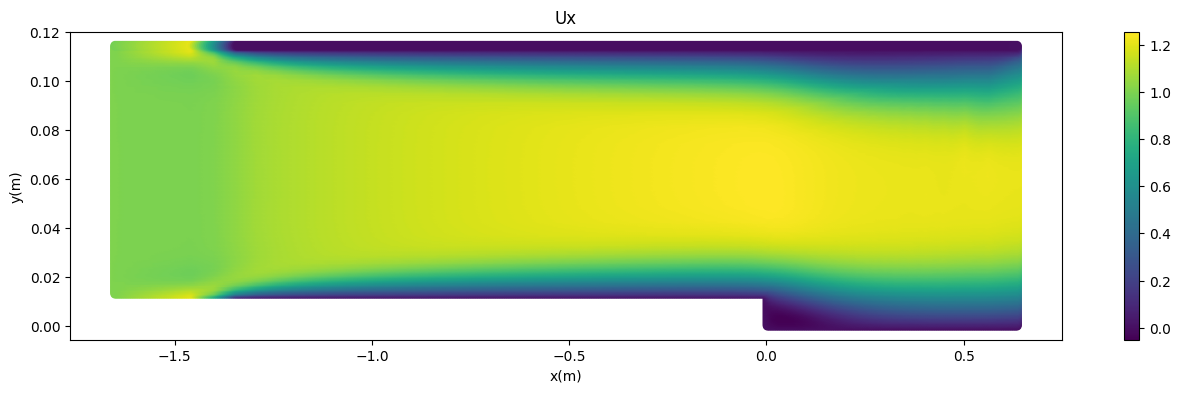

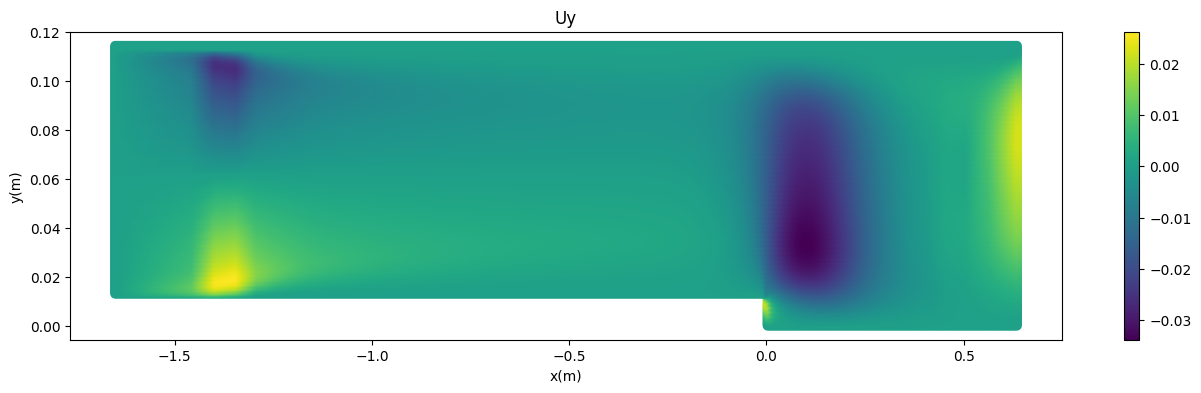

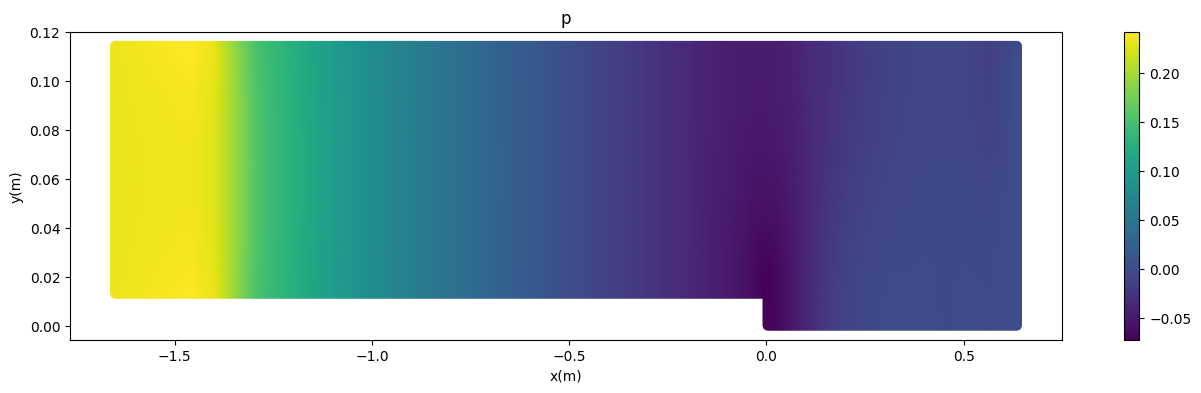

In [3]:
# Visualização dos campos de velocidade e pressão
df = pd.read_csv(PATH_DATA / "dataset_bfs_2d_grid.csv")
H = 0.0127
x = df["x"].values
y = df["y"].values
Ux = df["Ux"].values
Uy = df["Uy"].values

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Ux"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("Ux")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["Uy"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("Uy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["p"])
plt.colorbar()
plt.xlabel("x(m)")
plt.ylabel("y(m)")
plt.title("p")
plt.show()

## Visualizando região de Estudo (EDO 1)

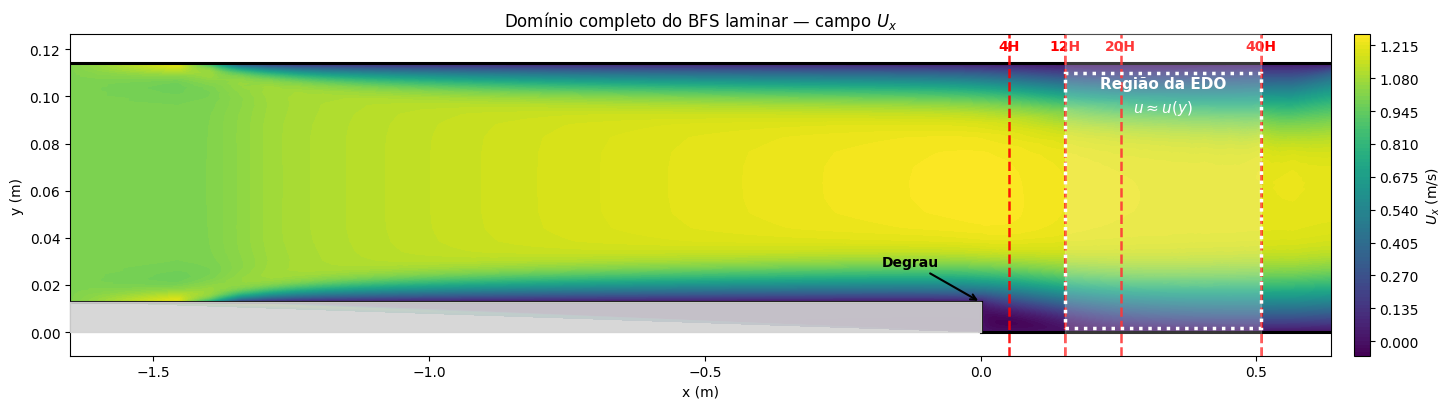

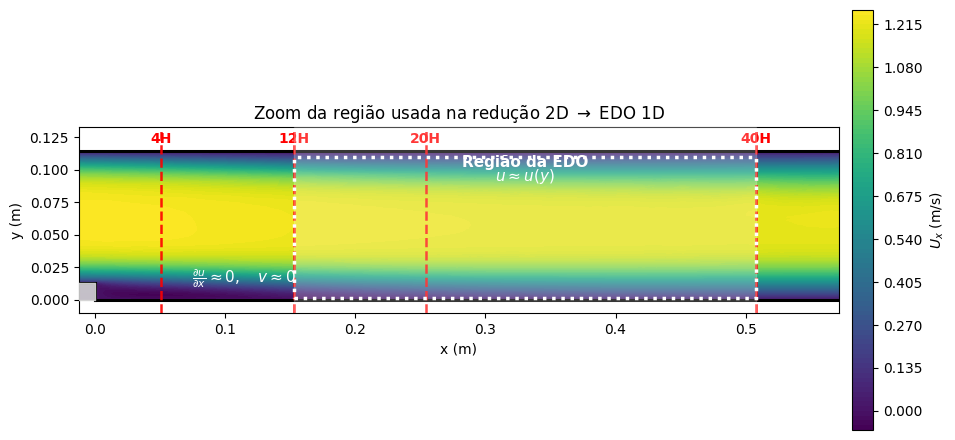

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

H = 0.0127

x = df["x"].values
y = df["y"].values
Ux = df["Ux"].values

xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

def desenhar_bfs(ax, xmin, xmax, H):
    ax.plot([xmin, 0], [H, H], color="black", linewidth=2.2)
    ax.plot([0, 0], [0, H], color="black", linewidth=2.2)
    ax.plot([0, xmax], [0, 0], color="black", linewidth=2.2)
    ax.plot([xmin, xmax], [9*H, 9*H], color="black", linewidth=2.2)

    ax.fill_between(
        [xmin, 0],
        0,
        H,
        color="lightgray",
        alpha=0.9,
        zorder=5
    )

def adicionar_linhas_H(ax, H, y_top, linhas=(4,12,20,40)):
    for xpos in linhas:
        xx = xpos * H
        ax.axvline(xx, color="red", linestyle="--", linewidth=1.8, alpha=0.9)
        ax.text(
            xx,
            y_top,
            f"{xpos}H",
            color="red",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

def destacar_regiao_edo(ax, H, x0_H=12, x1_H=40):
    x0 = x0_H * H
    x1 = x1_H * H

    ax.axvspan(
        x0,
        x1,
        color="white",
        alpha=0.22,
        zorder=7
    )

    ax.add_patch(
        Rectangle(
            (x0, 0.15*H),
            x1 - x0,
            8.5*H,
            fill=False,
            edgecolor="white",
            linewidth=2.5,
            linestyle=":",
            zorder=10
        )
    )

    ax.text(
        (x0 + x1) / 2,
        8.3 * H,
        "Região da EDO",
        color="white",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        zorder=11
    )

    ax.text(
        (x0 + x1) / 2,
        7.5 * H,
        r"$u \approx u(y)$",
        color="white",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        zorder=11
    )

# ============================================================
# FIGURA 1 — DOMÍNIO COMPLETO
# ============================================================

fig, ax = plt.subplots(figsize=(16, 4.2))

cont = ax.tricontourf(
    x,
    y,
    Ux,
    levels=100,
    cmap="viridis"
)

cbar = plt.colorbar(cont, ax=ax, pad=0.015)
cbar.set_label(r"$U_x$ (m/s)")

desenhar_bfs(ax, xmin, xmax, H)
adicionar_linhas_H(ax, H, ymax + 0.004)
destacar_regiao_edo(ax, H, x0_H=12, x1_H=40)

ax.annotate(
    "Degrau",
    xy=(0, H),
    xytext=(-10*H, 2.2*H),
    arrowprops=dict(arrowstyle="->", color="black", linewidth=1.5),
    fontsize=10,
    fontweight="bold",
    ha="center"
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(-0.01, ymax + 0.012)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(r"Domínio completo do BFS laminar — campo $U_x$")

ax.set_aspect("auto")
plt.tight_layout()
plt.show()

# ============================================================
# FIGURA 2 — ZOOM NA REGIÃO DA EDO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4.5))

cont = ax.tricontourf(
    x,
    y,
    Ux,
    levels=100,
    cmap="viridis"
)

cbar = plt.colorbar(cont, ax=ax, pad=0.015)
cbar.set_label(r"$U_x$ (m/s)")

desenhar_bfs(ax, xmin, xmax, H)
adicionar_linhas_H(ax, H, ymax + 0.004, linhas=(4, 12, 20, 40))
destacar_regiao_edo(ax, H, x0_H=12, x1_H=40)

ax.text(
    9*H,
    1.0*H,
    r"$\frac{\partial u}{\partial x} \approx 0,\quad v \approx 0$",
    color="white",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

ax.set_xlim(-1*H, 45*H)
ax.set_ylim(-0.002, 10*H + 0.006)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(r"Zoom da região usada na redução 2D $\rightarrow$ EDO 1D")

ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Visualização da Região de Recirculação

In [ ]:
# Pontos com Ux < 0 (Região de recirculação)
neg = df[df["Ux"] < 0]

print("Pontos com Ux < 0:", len(neg))
print(f"Percentual: {100*len(neg)/len(df):.4f}%")
print("Ux mínimo:", df["Ux"].min())

Pontos com Ux < 0: 390
Percentual: 0.3862%
Ux mínimo: -0.0508477


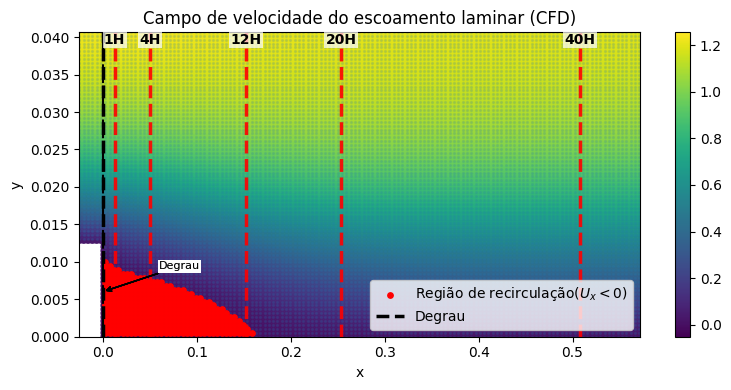

In [89]:
perfis = [1, 4, 12, 20, 40]

plt.figure(figsize=(8, 4))
plt.scatter(df["x"], df["y"], c=df["Ux"])
plt.colorbar()
plt.scatter(df["x"], df["y"], s=2, alpha=0.15)
plt.scatter(neg["x"], neg["y"], color="red", s=15, label=r"Região de recirculação($U_x < 0$)")

# Degrau
plt.axvline(
    x=0,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label="Degrau"
)

# Perfis utilizados na comparação
for xh in perfis:
    x = xh * H

    plt.axvline(
        x=x,
        color="red",
        linestyle="--",
        linewidth=2.5,
        alpha=0.9
    )

    plt.annotate(
        "Degrau",
        xy=(0,0.006),
        xytext=(0.06,0.009),
        arrowprops=dict(arrowstyle="->"),
        fontsize=8,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.7,
            pad=1
        )
    )

    plt.text(
        x,
        3.05*H,
        f"{xh}H",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.7,
            pad=1
        )
    )

plt.axvline(0, color="black", linestyle="--")
plt.xlim(-2*H, 45*H)
plt.ylim(0, 3.2*H)


plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo de velocidade do escoamento laminar (CFD)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cálculo do número de Reynolds
nu=5e-05
Re = 1*H/nu
print(Re)

253.99999999999997


# Estudo de modelagem (EDO X CFD)

In [19]:
def solve_mdf_edo(N, H, C, u_cfd_norm, eta_cfd, resultados):
    eta = np.linspace(0, 1, N)
    dy_eta = eta[1] - eta[0]

    print("Malha dy_eta:", dy_eta)
    print("Size da malha y:", eta.size)
    
    Aw = np.zeros(N)
    Ae = np.zeros(N)
    Ap = np.zeros(N)
    S = C * H**2 * np.ones_like(eta)

    for i in range(1, N-1):
        Aw[i] = 1/dy_eta**2
        Ae[i] = 1/dy_eta**2
        Ap[i] = -2/dy_eta**2

    Ap[0] = 1.0
    S[0] = 0.0

    Ap[N-1] = 1.0
    S[-1] = 0.0

    A = np.zeros((N, N))

    for i in range(1, N-1):
        A[i, i-1] = Aw[i]
        A[i, i] = Ap[i]
        A[i, i+1] = Ae[i]

    A[0, 0] = Ap[0]
    A[N-1, N-1] = Ap[N-1]

    e = np.zeros(N)
    b = np.copy(S)

    for i in range(1, N):
        e[i] = A[i, i-1] / A[i-1, i-1]
        A[i, i] = A[i, i] - e[i] * A[i-1, i]
        b[i] = b[i] - e[i] * b[i-1]
        A[i, i-1] = 0.0

    u_mdf = np.zeros(N)
    u_mdf[N-1] = b[N-1] / A[N-1, N-1]

    for i in range(N-2, -1, -1):
        u_mdf[i] = (b[i] - A[i, i+1] * u_mdf[i+1]) / A[i, i]

    u_mdf_norm = u_mdf / np.max(np.abs(u_mdf))

    u_cfd_interp = np.interp(eta, eta_cfd, u_cfd_norm)

    erro = u_mdf_norm - u_cfd_interp

    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro**2))
    l2_rel = np.linalg.norm(erro) / np.linalg.norm(u_cfd_interp)

    resultados.append([N, dy_eta, mae, rmse, l2_rel])

    return eta, u_mdf_norm, u_cfd_interp, resultados

## Solução MDF para diferentes perfis de escoamento

Processando perfil: dataset_bfs_2d_x_by_h_1
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


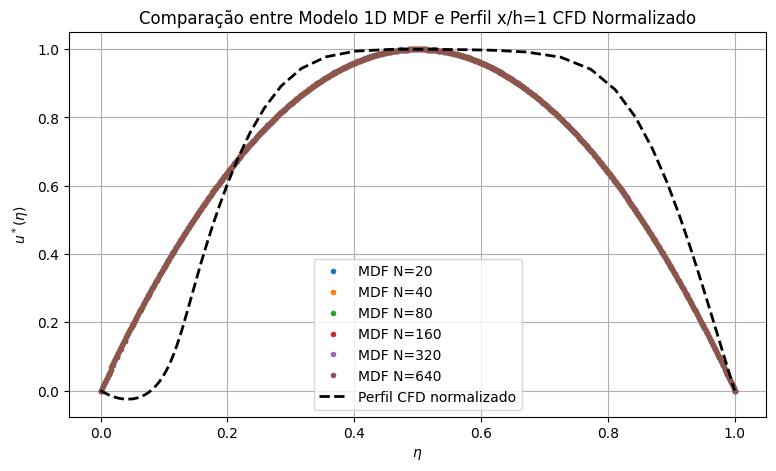

Processando perfil: dataset_bfs_2d_x_by_h_2
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


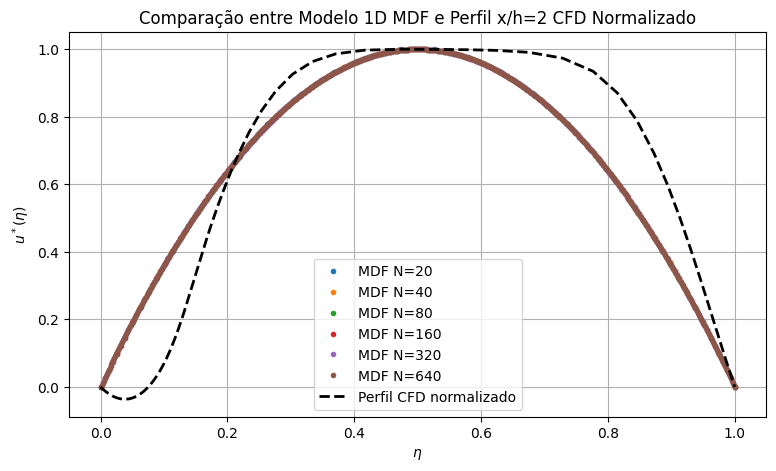

Processando perfil: dataset_bfs_2d_x_by_h_4
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


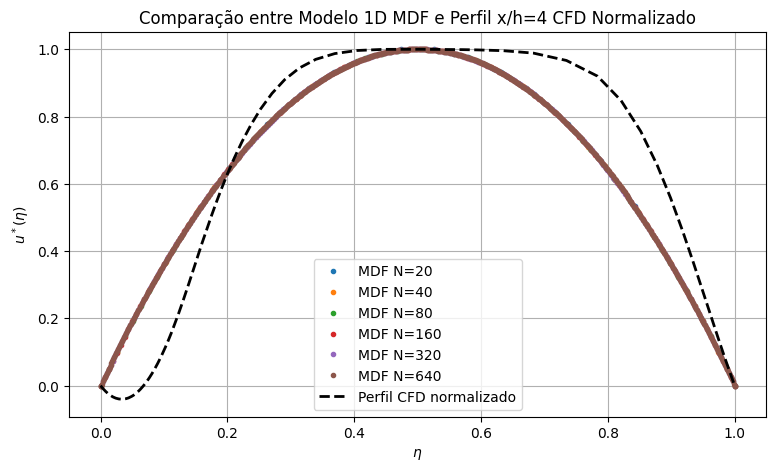

Processando perfil: dataset_bfs_2d_x_by_h_10
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


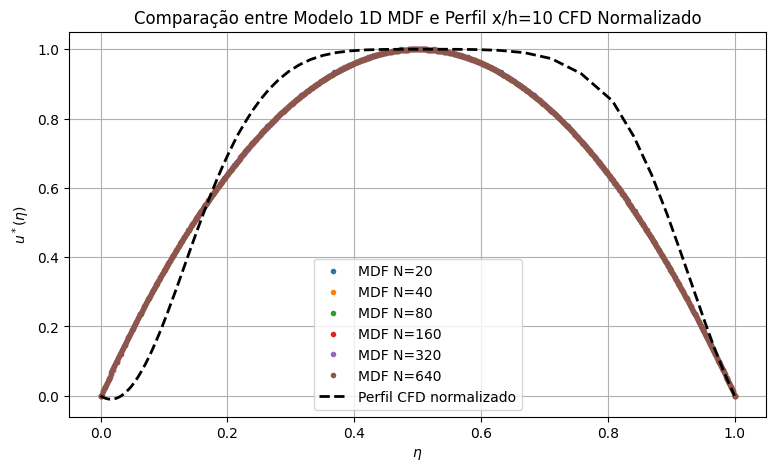

Processando perfil: dataset_bfs_2d_x_by_h_12
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


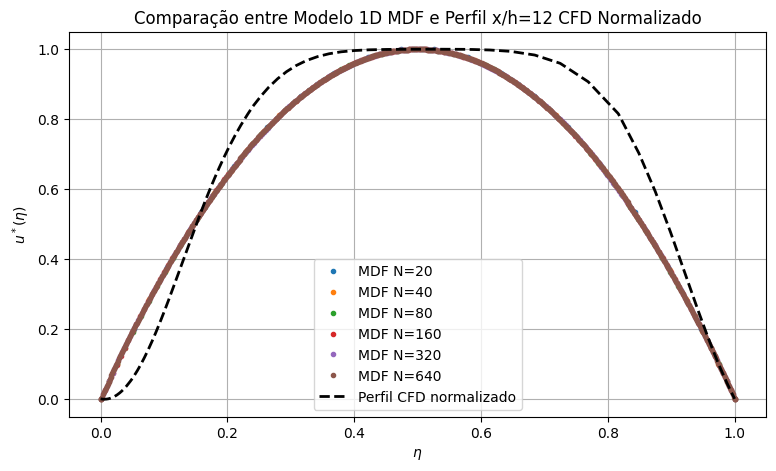

Processando perfil: dataset_bfs_2d_x_by_h_20
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


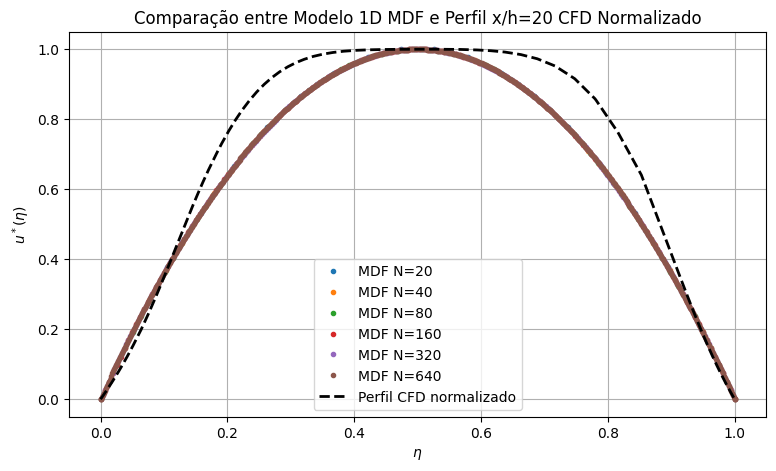

Processando perfil: dataset_bfs_2d_x_by_h_25
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


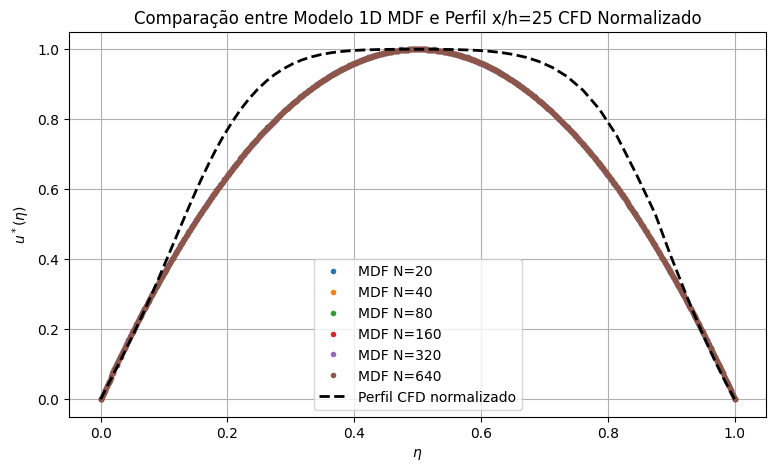

Processando perfil: dataset_bfs_2d_x_by_h_30
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


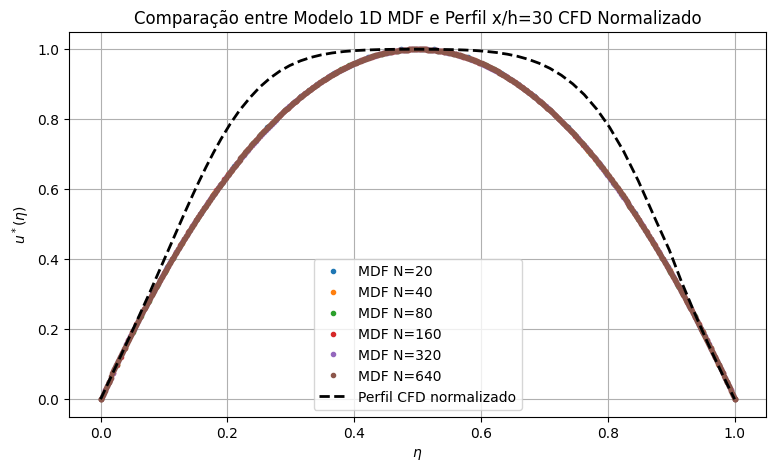

Processando perfil: dataset_bfs_2d_x_by_h_40
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


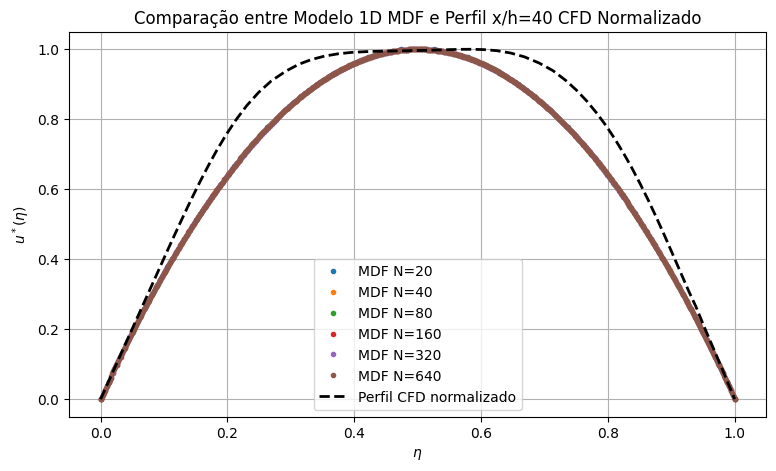

In [16]:
profiles = ["dataset_bfs_2d_x_by_h_1","dataset_bfs_2d_x_by_h_2", "dataset_bfs_2d_x_by_h_4", 
            "dataset_bfs_2d_x_by_h_10", "dataset_bfs_2d_x_by_h_12", "dataset_bfs_2d_x_by_h_20",
            "dataset_bfs_2d_x_by_h_25", "dataset_bfs_2d_x_by_h_30", "dataset_bfs_2d_x_by_h_40"]
for profile_name in profiles:
    print(f"Processando perfil: {profile_name}")
    # Parâmetros do problema
    C = -1.0
    Ns = [20, 40, 80, 160, 320, 640]
    resultados = []

    # Dados CFD
    df_cfd = pd.read_csv(PATH_DATA / f"{profile_name}.csv")
    y_cfd = df_cfd["y"].values
    u_cfd = df_cfd["Ux"].values

    # ordenar por y
    idx = np.argsort(y_cfd)
    y_cfd = y_cfd[idx]
    u_cfd = u_cfd[idx]

    H = y_cfd.max() - y_cfd.min()

    # eta do CFD
    eta_cfd = (y_cfd - y_cfd.min()) / H

    # normalizar CFD
    u_cfd_norm = u_cfd / np.max(np.abs(u_cfd))

    plt.figure(figsize=(9, 5))

    for N in Ns:
        y_eta, u_mdf, u_ref, resultados = solve_mdf_edo(N, H, C, u_cfd_norm, eta_cfd, resultados)
        plt.plot(y_eta, u_mdf, "o", markersize=3, label=f"MDF N={N}")

    # CFD em malha fina
    eta_fino = np.linspace(0, 1, 1000)
    u_cfd_fino = np.interp(eta_fino, eta_cfd, u_cfd_norm)

    plt.plot(
        eta_fino,
        u_cfd_fino,
        "k--",
        linewidth=2,
        label="Perfil CFD normalizado"
    )

    plt.xlabel(r"$\eta$")
    plt.ylabel(r"$u^*(\eta)$")
    plt.title(f"Comparação entre Modelo 1D MDF e Perfil x/h={profile_name.split('_')[-1]} CFD Normalizado")
    plt.grid(True)
    plt.legend()
    plt.show()

## Métricas do método

     N   2N       MAE      RMSE    L2_rel
0   20   40  0.001754  0.001977  0.002778
1   40   80  0.000427  0.000474  0.000658
2   80  160  0.000105  0.000116  0.000160
3  160  320  0.000026  0.000029  0.000040
4  320  640  0.000007  0.000007  0.000010


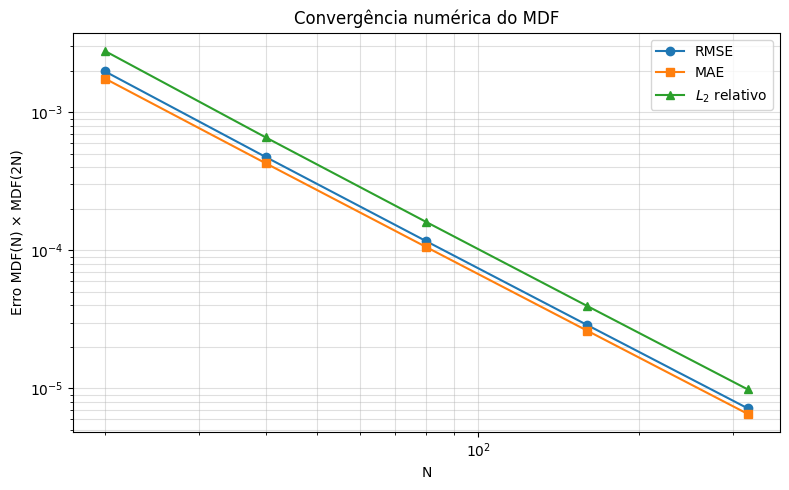

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def solve_mdf_only(N, H=1.0, C=-1.0):
    eta = np.linspace(0, 1, N)
    h = H / (N - 1)

    A = np.zeros((N, N))
    b = np.zeros(N)

    # Condições de contorno
    A[0, 0] = 1.0
    b[0] = 0.0

    A[-1, -1] = 1.0
    b[-1] = 0.0

    # Pontos internos
    for i in range(1, N - 1):
        A[i, i - 1] = 1.0 / h**2
        A[i, i] = -2.0 / h**2
        A[i, i + 1] = 1.0 / h**2
        b[i] = C

    u = np.linalg.solve(A, b)

    # Normalizar
    u = u / np.max(np.abs(u))

    return eta, u


Ns = [20, 40, 80, 160, 320]
solucoes = {}

for N in Ns + [640]:
    eta, u = solve_mdf_only(N, H=1.0, C=-1.0)
    solucoes[N] = {"eta": eta, "u": u}

resultados = []

for N in Ns:
    eta_N = solucoes[N]["eta"]
    u_N = solucoes[N]["u"]

    eta_2N = solucoes[2*N]["eta"]
    u_2N = solucoes[2*N]["u"]

    u_2N_interp = np.interp(eta_N, eta_2N, u_2N)

    erro = u_N - u_2N_interp

    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro**2))
    l2_rel = np.linalg.norm(erro) / np.linalg.norm(u_2N_interp)

    resultados.append([N, 2*N, mae, rmse, l2_rel])

df_conv = pd.DataFrame(
    resultados,
    columns=["N", "2N", "MAE", "RMSE", "L2_rel"]
)

print(df_conv)

plt.figure(figsize=(8, 5))
plt.loglog(df_conv["N"], df_conv["RMSE"], "o-", label="RMSE")
plt.loglog(df_conv["N"], df_conv["MAE"], "s-", label="MAE")
plt.loglog(df_conv["N"], df_conv["L2_rel"], "^-", label=r"$L_2$ relativo")

plt.ylabel("Erro MDF(N) × MDF(2N)")
plt.title("Convergência numérica do MDF")
plt.grid(True, which="both", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


Processando perfil x/H=1
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


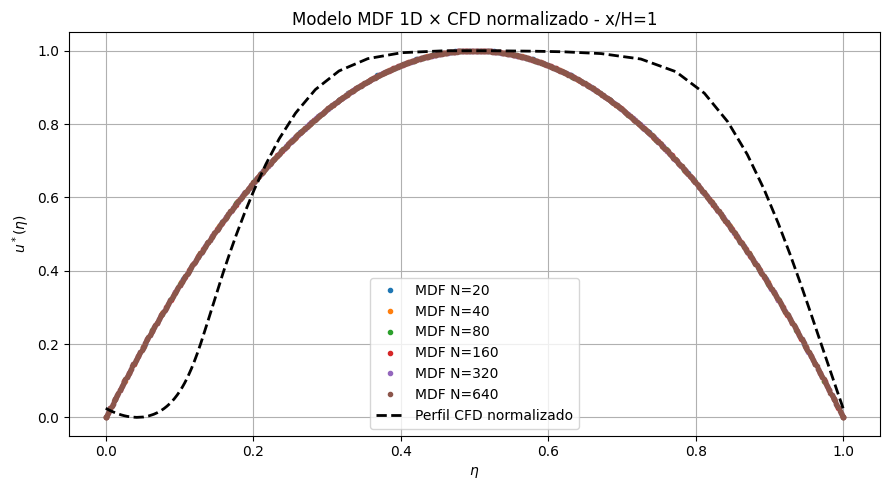

N=  20 | h=5.2632e-02 | MAE=1.0982e-01 | RMSE=1.4637e-01 | L2=1.8858e-01
N=  40 | h=2.5641e-02 | MAE=1.1435e-01 | RMSE=1.4862e-01 | L2=1.8901e-01
N=  80 | h=1.2658e-02 | MAE=1.1560e-01 | RMSE=1.4958e-01 | L2=1.8904e-01
N= 160 | h=6.2893e-03 | MAE=1.1614e-01 | RMSE=1.5006e-01 | L2=1.8905e-01
N= 320 | h=3.1348e-03 | MAE=1.1643e-01 | RMSE=1.5029e-01 | L2=1.8905e-01
N= 640 | h=1.5649e-03 | MAE=1.1657e-01 | RMSE=1.5041e-01 | L2=1.8904e-01


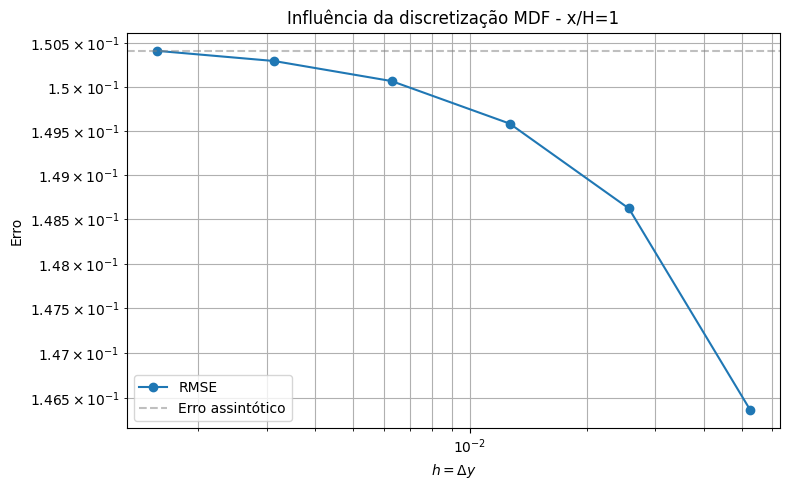


Processando perfil x/H=2
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


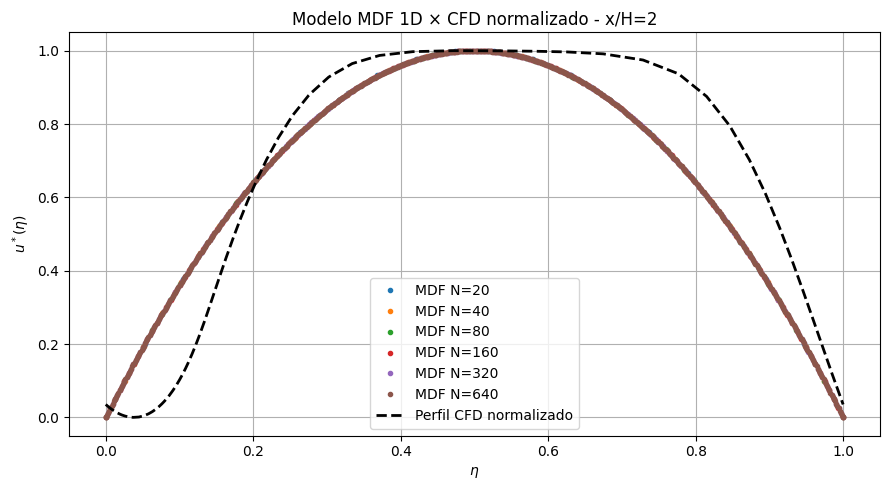

N=  20 | h=5.2632e-02 | MAE=1.0794e-01 | RMSE=1.4153e-01 | L2=1.8209e-01
N=  40 | h=2.5641e-02 | MAE=1.1182e-01 | RMSE=1.4381e-01 | L2=1.8262e-01
N=  80 | h=1.2658e-02 | MAE=1.1294e-01 | RMSE=1.4463e-01 | L2=1.8251e-01
N= 160 | h=6.2893e-03 | MAE=1.1332e-01 | RMSE=1.4508e-01 | L2=1.8251e-01
N= 320 | h=3.1348e-03 | MAE=1.1360e-01 | RMSE=1.4531e-01 | L2=1.8250e-01
N= 640 | h=1.5649e-03 | MAE=1.1373e-01 | RMSE=1.4542e-01 | L2=1.8250e-01


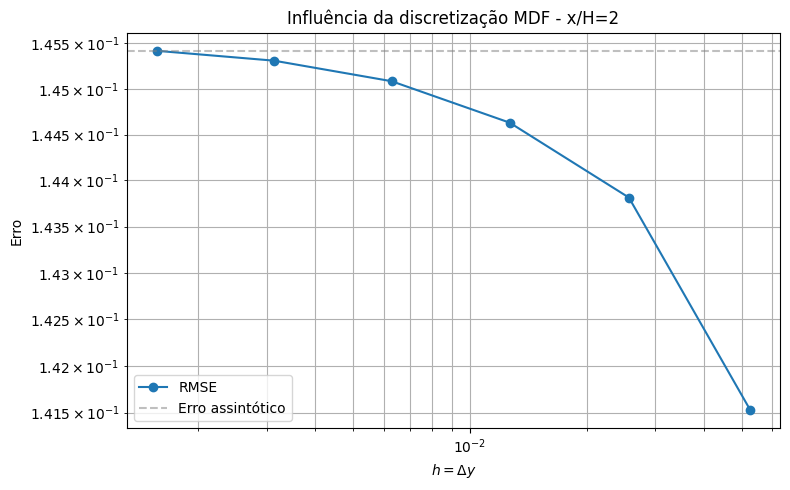


Processando perfil x/H=4
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


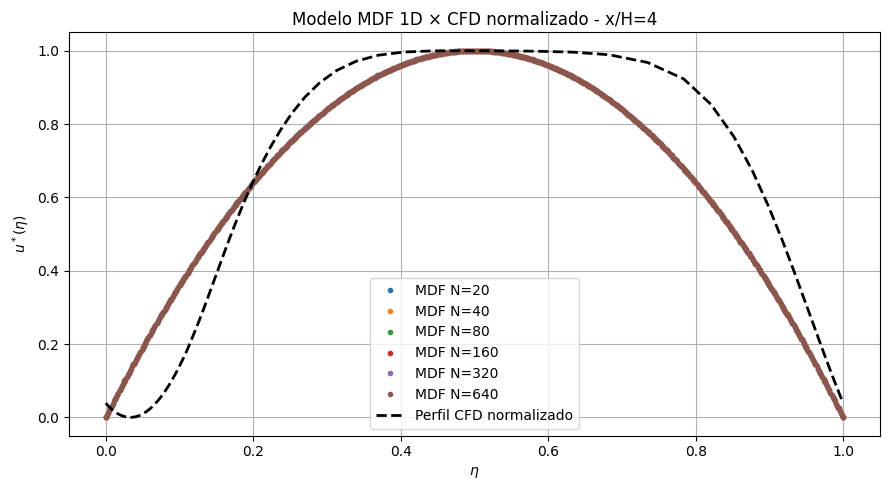

N=  20 | h=5.2632e-02 | MAE=1.0367e-01 | RMSE=1.3331e-01 | L2=1.7132e-01
N=  40 | h=2.5641e-02 | MAE=1.0644e-01 | RMSE=1.3525e-01 | L2=1.7163e-01
N=  80 | h=1.2658e-02 | MAE=1.0737e-01 | RMSE=1.3611e-01 | L2=1.7162e-01
N= 160 | h=6.2893e-03 | MAE=1.0766e-01 | RMSE=1.3649e-01 | L2=1.7156e-01
N= 320 | h=3.1348e-03 | MAE=1.0791e-01 | RMSE=1.3671e-01 | L2=1.7156e-01
N= 640 | h=1.5649e-03 | MAE=1.0802e-01 | RMSE=1.3681e-01 | L2=1.7155e-01


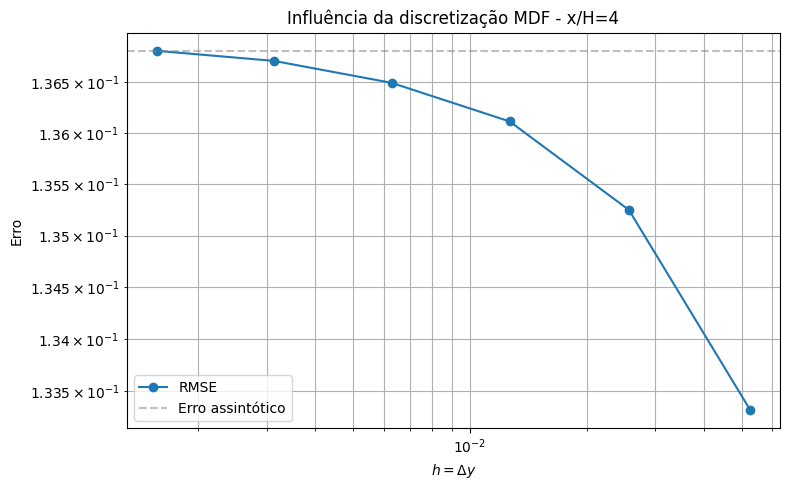


Processando perfil x/H=10
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


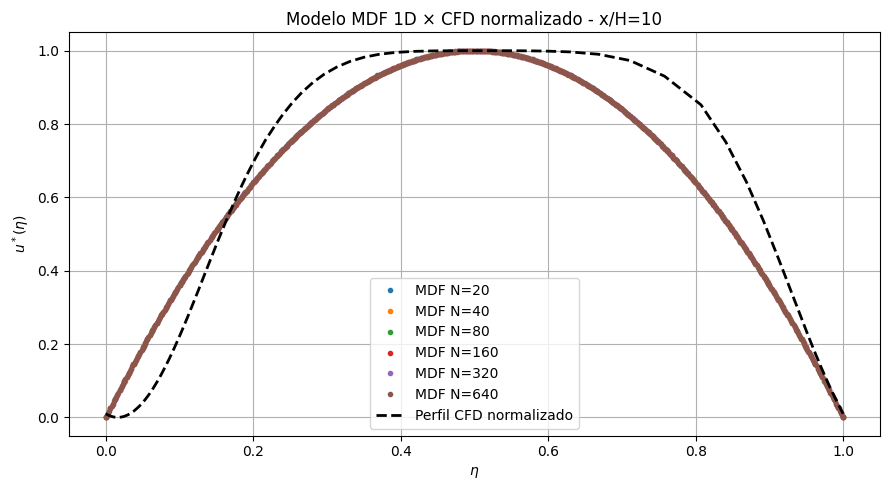

N=  20 | h=5.2632e-02 | MAE=8.3025e-02 | RMSE=1.0738e-01 | L2=1.3830e-01
N=  40 | h=2.5641e-02 | MAE=8.6846e-02 | RMSE=1.0968e-01 | L2=1.3942e-01
N=  80 | h=1.2658e-02 | MAE=8.8164e-02 | RMSE=1.1067e-01 | L2=1.3978e-01
N= 160 | h=6.2893e-03 | MAE=8.8700e-02 | RMSE=1.1107e-01 | L2=1.3984e-01
N= 320 | h=3.1348e-03 | MAE=8.8946e-02 | RMSE=1.1125e-01 | L2=1.3986e-01
N= 640 | h=1.5649e-03 | MAE=8.9068e-02 | RMSE=1.1134e-01 | L2=1.3986e-01


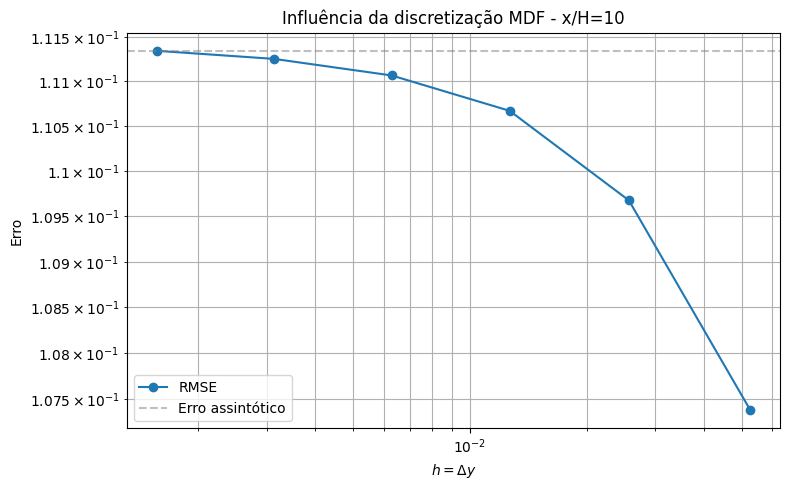


Processando perfil x/H=12
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


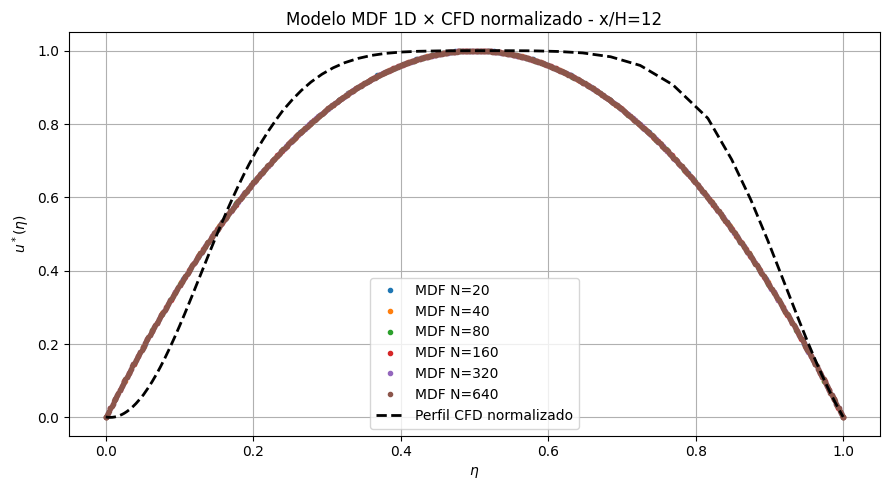

N=  20 | h=5.2632e-02 | MAE=7.5718e-02 | RMSE=9.9787e-02 | L2=1.2860e-01
N=  40 | h=2.5641e-02 | MAE=8.0538e-02 | RMSE=1.0255e-01 | L2=1.3042e-01
N=  80 | h=1.2658e-02 | MAE=8.2037e-02 | RMSE=1.0327e-01 | L2=1.3051e-01
N= 160 | h=6.2893e-03 | MAE=8.2601e-02 | RMSE=1.0363e-01 | L2=1.3056e-01
N= 320 | h=3.1348e-03 | MAE=8.2882e-02 | RMSE=1.0380e-01 | L2=1.3057e-01
N= 640 | h=1.5649e-03 | MAE=8.3016e-02 | RMSE=1.0389e-01 | L2=1.3057e-01


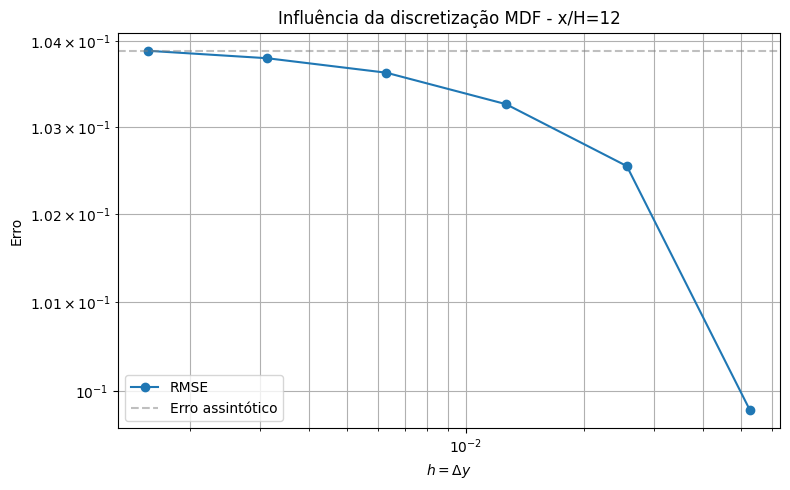


Processando perfil x/H=20
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


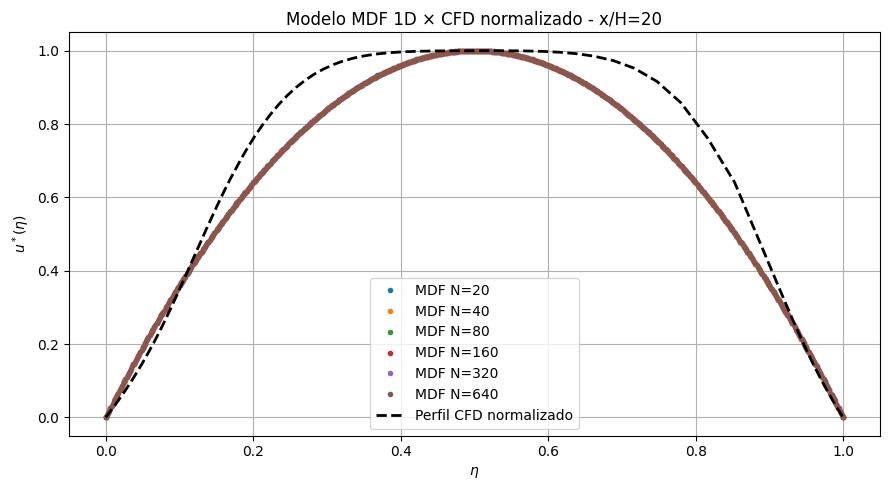

N=  20 | h=5.2632e-02 | MAE=6.3548e-02 | RMSE=8.4917e-02 | L2=1.0927e-01
N=  40 | h=2.5641e-02 | MAE=6.7441e-02 | RMSE=8.7179e-02 | L2=1.1073e-01
N=  80 | h=1.2658e-02 | MAE=6.8682e-02 | RMSE=8.7970e-02 | L2=1.1103e-01
N= 160 | h=6.2893e-03 | MAE=6.9197e-02 | RMSE=8.8344e-02 | L2=1.1115e-01
N= 320 | h=3.1348e-03 | MAE=6.9440e-02 | RMSE=8.8497e-02 | L2=1.1117e-01
N= 640 | h=1.5649e-03 | MAE=6.9553e-02 | RMSE=8.8569e-02 | L2=1.1117e-01


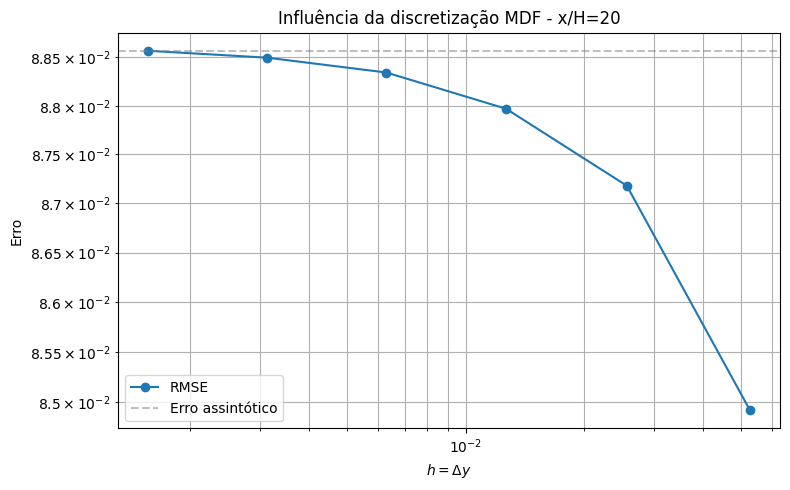


Processando perfil x/H=25
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


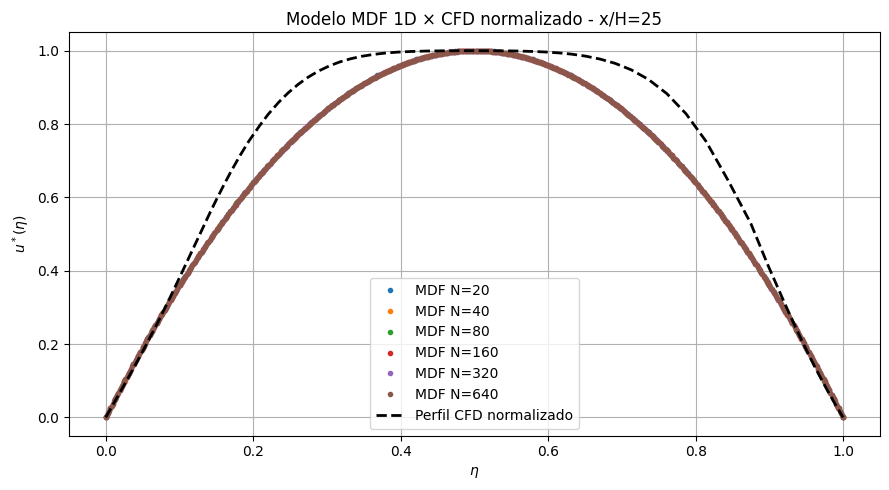

N=  20 | h=5.2632e-02 | MAE=6.1478e-02 | RMSE=8.2008e-02 | L2=1.0559e-01
N=  40 | h=2.5641e-02 | MAE=6.4545e-02 | RMSE=8.4286e-02 | L2=1.0712e-01
N=  80 | h=1.2658e-02 | MAE=6.5771e-02 | RMSE=8.5126e-02 | L2=1.0750e-01
N= 160 | h=6.2893e-03 | MAE=6.6292e-02 | RMSE=8.5471e-02 | L2=1.0759e-01
N= 320 | h=3.1348e-03 | MAE=6.6515e-02 | RMSE=8.5612e-02 | L2=1.0760e-01
N= 640 | h=1.5649e-03 | MAE=6.6625e-02 | RMSE=8.5684e-02 | L2=1.0761e-01


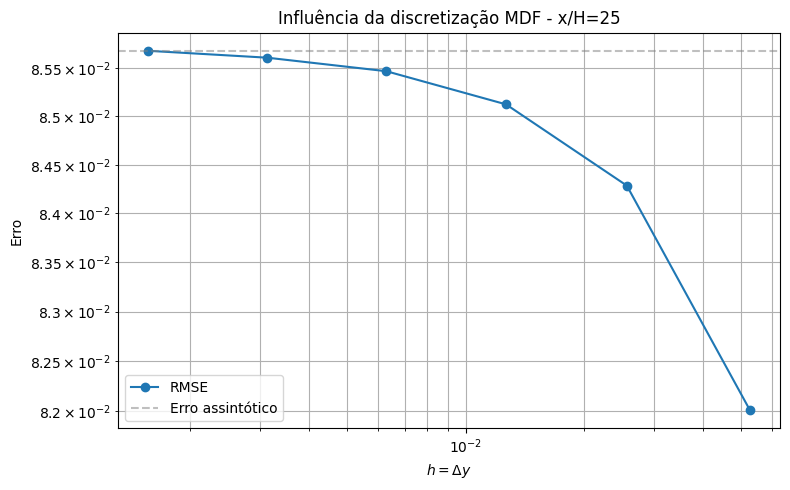


Processando perfil x/H=30
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


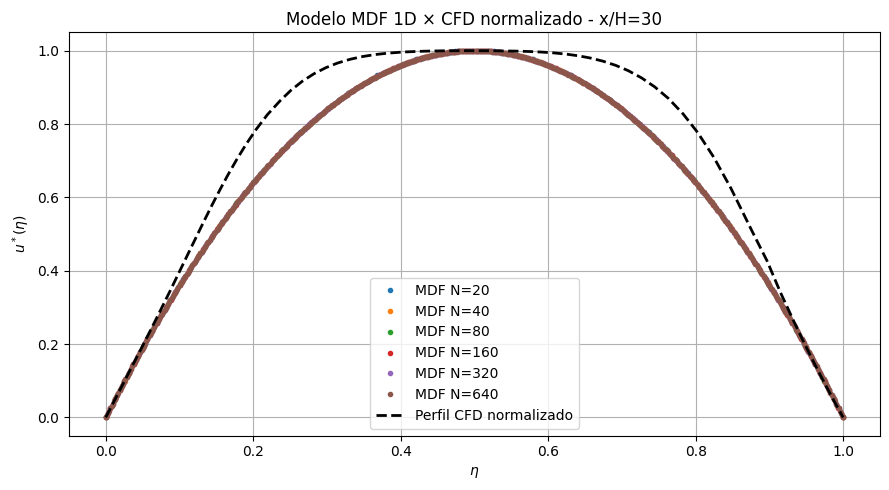

N=  20 | h=5.2632e-02 | MAE=6.0871e-02 | RMSE=8.0478e-02 | L2=1.0371e-01
N=  40 | h=2.5641e-02 | MAE=6.3842e-02 | RMSE=8.2615e-02 | L2=1.0510e-01
N=  80 | h=1.2658e-02 | MAE=6.4988e-02 | RMSE=8.3396e-02 | L2=1.0542e-01
N= 160 | h=6.2893e-03 | MAE=6.5472e-02 | RMSE=8.3710e-02 | L2=1.0548e-01
N= 320 | h=3.1348e-03 | MAE=6.5700e-02 | RMSE=8.3861e-02 | L2=1.0551e-01
N= 640 | h=1.5649e-03 | MAE=6.5807e-02 | RMSE=8.3930e-02 | L2=1.0551e-01


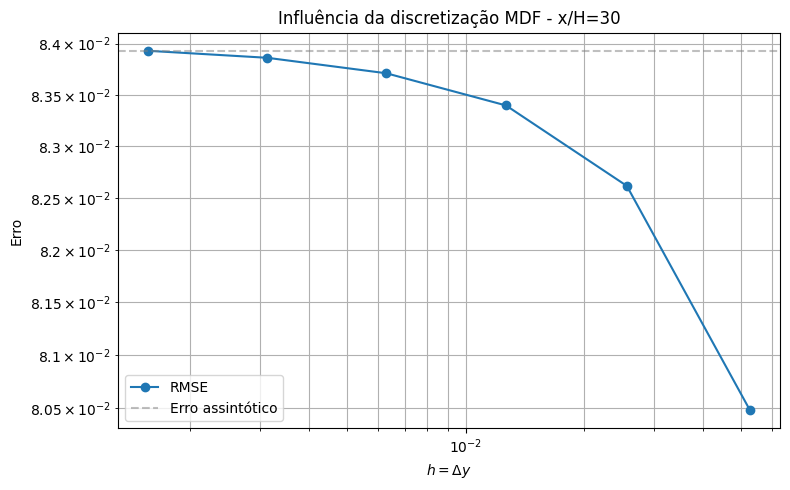


Processando perfil x/H=40
Malha dy_eta: 0.05263157894736842
Size da malha y: 20
Malha dy_eta: 0.02564102564102564
Size da malha y: 40
Malha dy_eta: 0.012658227848101266
Size da malha y: 80
Malha dy_eta: 0.006289308176100629
Size da malha y: 160
Malha dy_eta: 0.003134796238244514
Size da malha y: 320
Malha dy_eta: 0.001564945226917058
Size da malha y: 640


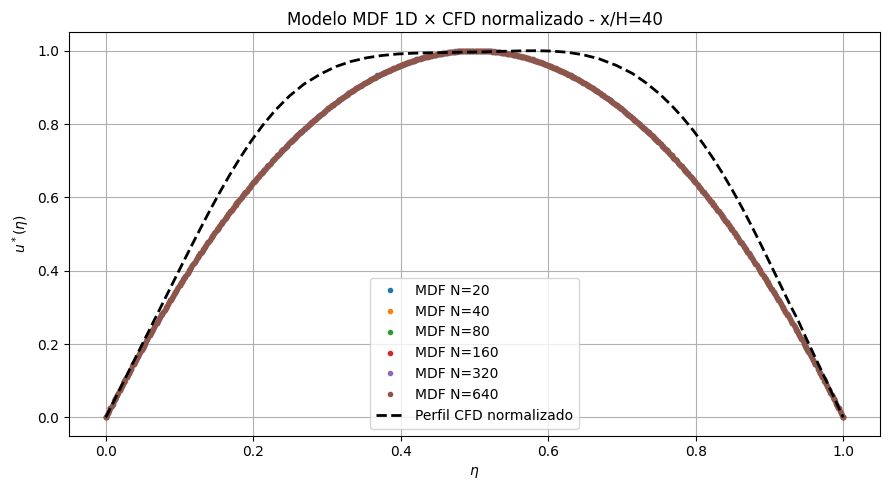

N=  20 | h=5.2632e-02 | MAE=6.0746e-02 | RMSE=7.7079e-02 | L2=9.9665e-02
N=  40 | h=2.5641e-02 | MAE=6.3420e-02 | RMSE=7.9279e-02 | L2=1.0118e-01
N=  80 | h=1.2658e-02 | MAE=6.4567e-02 | RMSE=8.0064e-02 | L2=1.0154e-01
N= 160 | h=6.2893e-03 | MAE=6.5026e-02 | RMSE=8.0363e-02 | L2=1.0160e-01
N= 320 | h=3.1348e-03 | MAE=6.5252e-02 | RMSE=8.0512e-02 | L2=1.0162e-01
N= 640 | h=1.5649e-03 | MAE=6.5359e-02 | RMSE=8.0580e-02 | L2=1.0163e-01


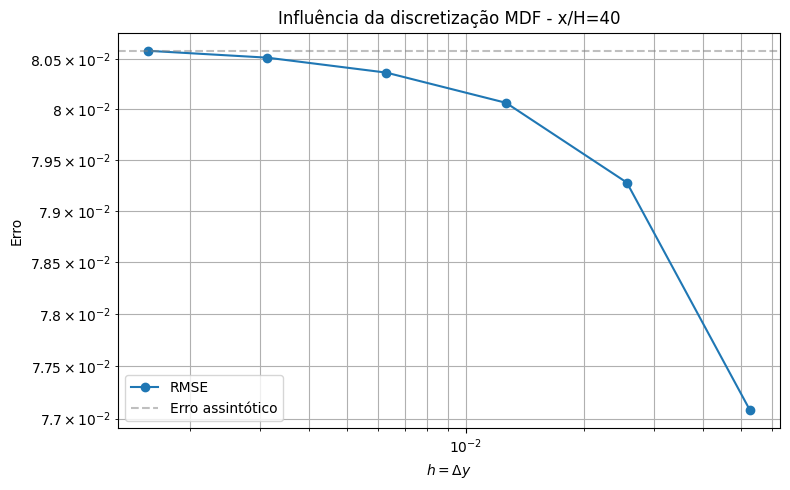

In [29]:
profiles = ["dataset_bfs_2d_x_by_h_1","dataset_bfs_2d_x_by_h_2", "dataset_bfs_2d_x_by_h_4", 
            "dataset_bfs_2d_x_by_h_10", "dataset_bfs_2d_x_by_h_12", "dataset_bfs_2d_x_by_h_20",
            "dataset_bfs_2d_x_by_h_25", "dataset_bfs_2d_x_by_h_30", "dataset_bfs_2d_x_by_h_40"]

Ns = [20, 40, 80, 160, 320, 640]
N_REF = 320
C = -1.0

resumo_xH = []

for profile_name in profiles:
    xH = int(profile_name.split("_")[-1])

    print(f"\nProcessando perfil x/H={xH}")

    resultados = []

    # Dados CFD
    df_cfd = pd.read_csv(PATH_DATA / f"{profile_name}.csv")

    y_cfd = df_cfd["y"].values
    u_cfd = df_cfd["Ux"].values

    # Ordenar por y
    idx = np.argsort(y_cfd)
    y_cfd = y_cfd[idx]
    u_cfd = u_cfd[idx]

    H_profile = y_cfd.max() - y_cfd.min()
    eta_cfd = (y_cfd - y_cfd.min()) / H_profile

    # Normalização min-max
    u_cfd_norm = (u_cfd - u_cfd.min()) / (u_cfd.max() - u_cfd.min())

    plt.figure(figsize=(9, 5))

    for N in Ns:
        y_eta, u_mdf, u_ref, resultados = solve_mdf_edo(
            N, H_profile, C, u_cfd_norm, eta_cfd, resultados
        )

        plt.plot(
            y_eta,
            u_mdf,
            "o",
            markersize=3,
            label=f"MDF N={N}"
        )

    # CFD interpolado
    eta_fino = np.linspace(0, 1, 1000)
    u_cfd_fino = np.interp(eta_fino, eta_cfd, u_cfd_norm)

    plt.plot(
        eta_fino,
        u_cfd_fino,
        "k--",
        linewidth=2,
        label="Perfil CFD normalizado"
    )

    plt.xlabel(r"$\eta$")
    plt.ylabel(r"$u^*(\eta)$")
    plt.title(f"Modelo MDF 1D × CFD normalizado - x/H={xH}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    for r in resultados:
        print(
            f"N={r[0]:4d} | h={r[1]:.4e} | "
            f"MAE={r[2]:.4e} | RMSE={r[3]:.4e} | L2={r[4]:.4e}"
        )

    resultados = np.array(resultados)

    # Gráfico erro x N
    plt.figure(figsize=(8, 5))
    plt.loglog(resultados[:, 1], resultados[:, 3], "o-", label="RMSE")
    plt.axhline(
        resultados[:,3][-1],
        color="gray",
        ls="--",
        alpha=0.5,
        label="Erro assintótico"
    )
    plt.xlabel(r"$h=\Delta y$")
    plt.ylabel("Erro")
    plt.title(f"Influência da discretização MDF - x/H={xH}")
    plt.grid(True, which="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Guardar resultado para N_REF
    idx_ref = np.where(resultados[:, 0] == N_REF)[0][0]

    resumo_xH.append({
        "xH": xH,
        "N": N_REF,
        "MAE": resultados[idx_ref, 2],
        "RMSE": resultados[idx_ref, 3],
        "L2": resultados[idx_ref, 4],
    })

   xH    N       MAE      RMSE        L2
0   1  320  0.116431  0.150294  0.189046
1   2  320  0.113601  0.145307  0.182505
2   4  320  0.107908  0.136710  0.171564
3  10  320  0.088946  0.111252  0.139855
4  12  320  0.082882  0.103800  0.130567
5  20  320  0.069440  0.088497  0.111170
6  25  320  0.066515  0.085612  0.107600
7  30  320  0.065700  0.083861  0.105508
8  40  320  0.065252  0.080512  0.101623


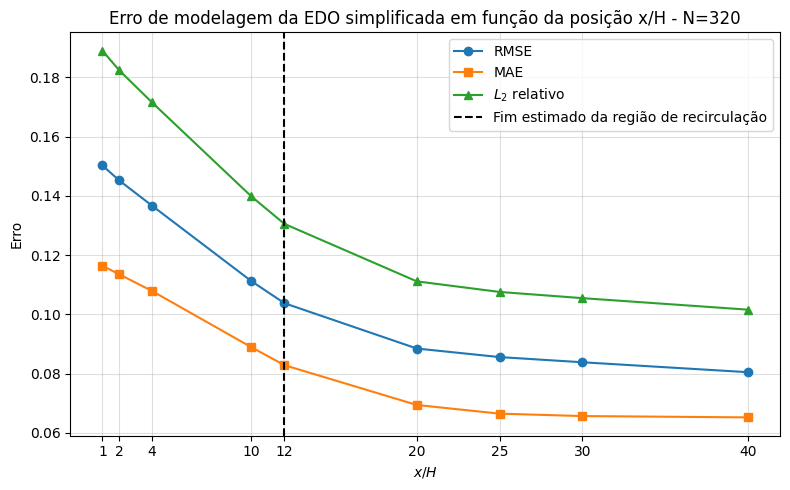

In [25]:
df_resumo_xH = pd.DataFrame(resumo_xH).sort_values("xH")

print(df_resumo_xH)

plt.figure(figsize=(8, 5))

plt.plot(df_resumo_xH["xH"], df_resumo_xH["RMSE"], "o-", label="RMSE")
plt.plot(df_resumo_xH["xH"], df_resumo_xH["MAE"], "s-", label="MAE")
plt.plot(df_resumo_xH["xH"], df_resumo_xH["L2"], "^-", label=r"$L_2$ relativo")

plt.axvline(12, color="black", linestyle="--", linewidth=1.5, label="Fim estimado da região de recirculação")

plt.xlabel(r"$x/H$")
plt.xticks([1, 2, 4, 10, 12, 20, 25, 30, 40])
plt.ylabel("Erro")
plt.title(f"Erro de modelagem da EDO simplificada em função da posição x/H - N={N_REF}")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Insights
O refinamento da malha reduz pouco o erro MDF–CFD, indicando que a principal discrepância decorre das hipóteses do modelo 1D. Além disso, observa-se redução progressiva do erro para maiores valores de x/H, sugerindo que o modelo simplificado se torna mais representativo em regiões mais afastadas do degrau.

Isso indica que o erro diminui conforme o perfil é extraído mais distante do degrau. Essa tendência é fisicamente esperada: longe da recirculação, o escoamento tende a ficar mais próximo de um perfil desenvolvido, então o modelo 1D parabólico representa melhor o CFD.

Também está correto o erro reduzir pouco quando N aumenta. Isso mostra que o erro dominante não é mais de discretização, mas de modelagem física.